In [1]:
from idlelib import history

"""
完整训练流程
load data -> mini batch ->  forward ->loss ->backward ->update ->evalute
"""

''

In [2]:
from collections import defaultdict
import math
import dnnlpy
import dnnlpy.models.mlp as mlp
import matplotlib.pyplot as plt
import numpy as np
import torchvision.datasets as datasets

rng = np.random.default_rng(42)
print("Numpy version:", np.__version__)


Numpy version: 2.5.2


X_train shape: (60000, 784)
y_train shape: (60000,)
X_test shape: (10000, 784)
y_test shape: (10000,)


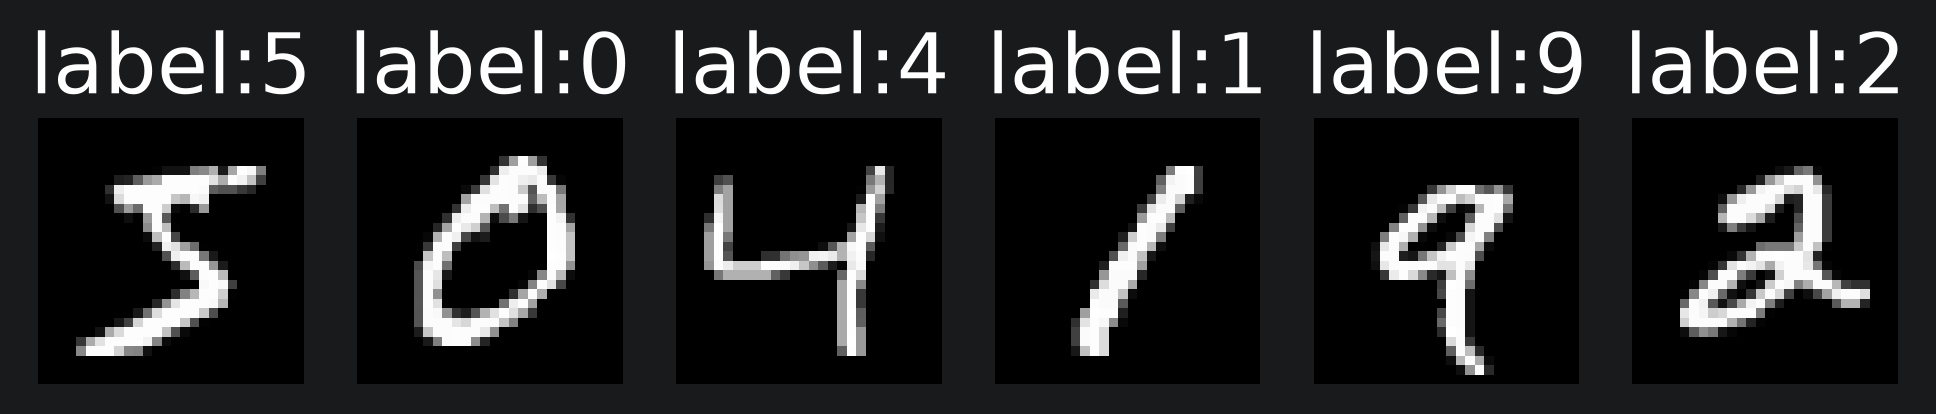

In [3]:
"""
准备MINIST的数据集
    - 使用reshape(-1,28*28) 把每张图片展平784维向量
    -  除以255,把像素从[0,255] 缩放到[0,1]
"""

root = dnnlpy.get_data_root()
train_ds = datasets.MNIST(root=root, train=True, download=True)
test_ds = datasets.MNIST(root=root, train=False, download=True)

x_train = train_ds.data.numpy()
x_train = np.reshape(x_train, (-1, 28 * 28))
x_train = x_train.astype(np.float32) / 255.0
y_train = train_ds.targets.numpy()

x_test = test_ds.data.numpy()
x_test = np.reshape(x_test, (-1, 28 * 28))
x_test = x_test.astype(np.float32) / 255.0
y_test = test_ds.targets.numpy()

print("X_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)

fig = plt.figure(1, figsize=(8, 2))
axes = fig.subplots(1, 6)
for i, ax in enumerate(axes.ravel()):
    ax.imshow(x_train[i].reshape(28, 28), cmap='gray')
    ax.axis('off')
    ax.set_title(f"label:{y_train[i]}", fontsize=20)
dnnlpy.set_matplotlib_format('highdpi')
plt.show()



In [8]:
"""
Mini-batch 数据迭代
"""


class DataLoader:
    def __init__(self, X: np.ndarray, y: np.ndarray, batch_size: int, shuffle: bool = True):
        self.X = X
        self.y = y
        self.batch_size = batch_size
        self.shuffle = shuffle

    def __iter__(self):
        indices = np.arange(len(self.X))

        if self.shuffle:
            rng.shuffle(indices)

        for start in range(0, len(self.X), self.batch_size):
            idx = indices[start:start + self.batch_size]
            yield self.X[idx], self.y[idx]

    def __len__(self):
        return math.ceil(len(self.X) // self.batch_size)



In [9]:
"""
计算Accuracy

"""


def accuracy(logits: np.ndarray, labels: np.ndarray) -> float:
    pred = np.argmax(logits, axis=1)
    correct = np.sum(pred == labels)
    return correct / len(labels)


In [10]:
"""
训练循环
    - model(X) 计算logits
    - loss_fn(logits,y_batch) 计算loss
    - loss_fn_backward() 得到关于logits的梯度
    - model.backward(dlogits) 把梯度传回每个参数
    - optimizer.step() 根据梯度更新参数
"""
train_dl = DataLoader(x_train, y_train, batch_size=128, shuffle=True)
test_dl = DataLoader(x_test, y_test, batch_size=128, shuffle=True)

model = mlp.MLP(input_dim=784, hidden_dim=256, num_classes=10)
loss_fn = mlp.CrossEntropyLoss()
optimizer = mlp.SGD(model.parameters(), lr=0.01)
history = defaultdict(list)

num_epochs = 10

for epoch in range(1, num_epochs + 1):
    train_loss = 0
    correct_sample = 0
    for X, y in train_dl:
        logits = model(X)
        loss = loss_fn(logits, y)

        dlogits = loss_fn.backward()
        dx = model.backward(dlogits)

        optimizer.step()
        optimizer.zero_grad()

        train_loss += loss.item()
        correct_sample += np.sum(np.argmax(logits, axis=1) == y)

    avg_train_loss = train_loss / len(train_dl)
    avg_train_acc = correct_sample / len(train_ds)
    history['loss'].append(avg_train_loss)
    history['acc'].append(avg_train_acc)

    test_loss = 0
    correct_sample = 0

    for X, y in test_dl:
        logits = model(X)
        loss = loss_fn(logits, y)

        test_loss += loss.item()
        correct_sample += np.sum(np.argmax(logits, axis=1) == y)
    avg_test_loss = train_loss / len(test_dl)
    avg_test_acc = correct_sample / len(test_ds)
    history['test_loss'].append(avg_test_loss)
    history['test_acc'].append(avg_test_acc)

    n = len(str(num_epochs))

    print(f"Epoch  [{epoch:{n}d}/{num_epochs:{n}d}]"
          f'| loss:{avg_train_loss:.4f}| '
          f'| acc:{avg_train_acc:.4f}| '
          f"| test_loss:{avg_test_loss:.4f}| "
          f"| test_acc:{avg_test_acc:.4f}"
          )




Epoch  [ 1/10]| loss:1.1349| | acc:0.7333| | test_loss:6.8093| | test_acc:0.8575
Epoch  [ 2/10]| loss:0.5410| | acc:0.8665| | test_loss:3.2460| | test_acc:0.8874
Epoch  [ 3/10]| loss:0.4349| | acc:0.8857| | test_loss:2.6096| | test_acc:0.8981
Epoch  [ 4/10]| loss:0.3872| | acc:0.8958| | test_loss:2.3231| | test_acc:0.9062
Epoch  [ 5/10]| loss:0.3577| | acc:0.9022| | test_loss:2.1460| | test_acc:0.9119
Epoch  [ 6/10]| loss:0.3370| | acc:0.9075| | test_loss:2.0223| | test_acc:0.9151
Epoch  [ 7/10]| loss:0.3209| | acc:0.9114| | test_loss:1.9252| | test_acc:0.9192
Epoch  [ 8/10]| loss:0.3077| | acc:0.9150| | test_loss:1.8460| | test_acc:0.9218
Epoch  [ 9/10]| loss:0.2963| | acc:0.9181| | test_loss:1.7778| | test_acc:0.9237
Epoch  [10/10]| loss:0.2863| | acc:0.9211| | test_loss:1.7179| | test_acc:0.9256


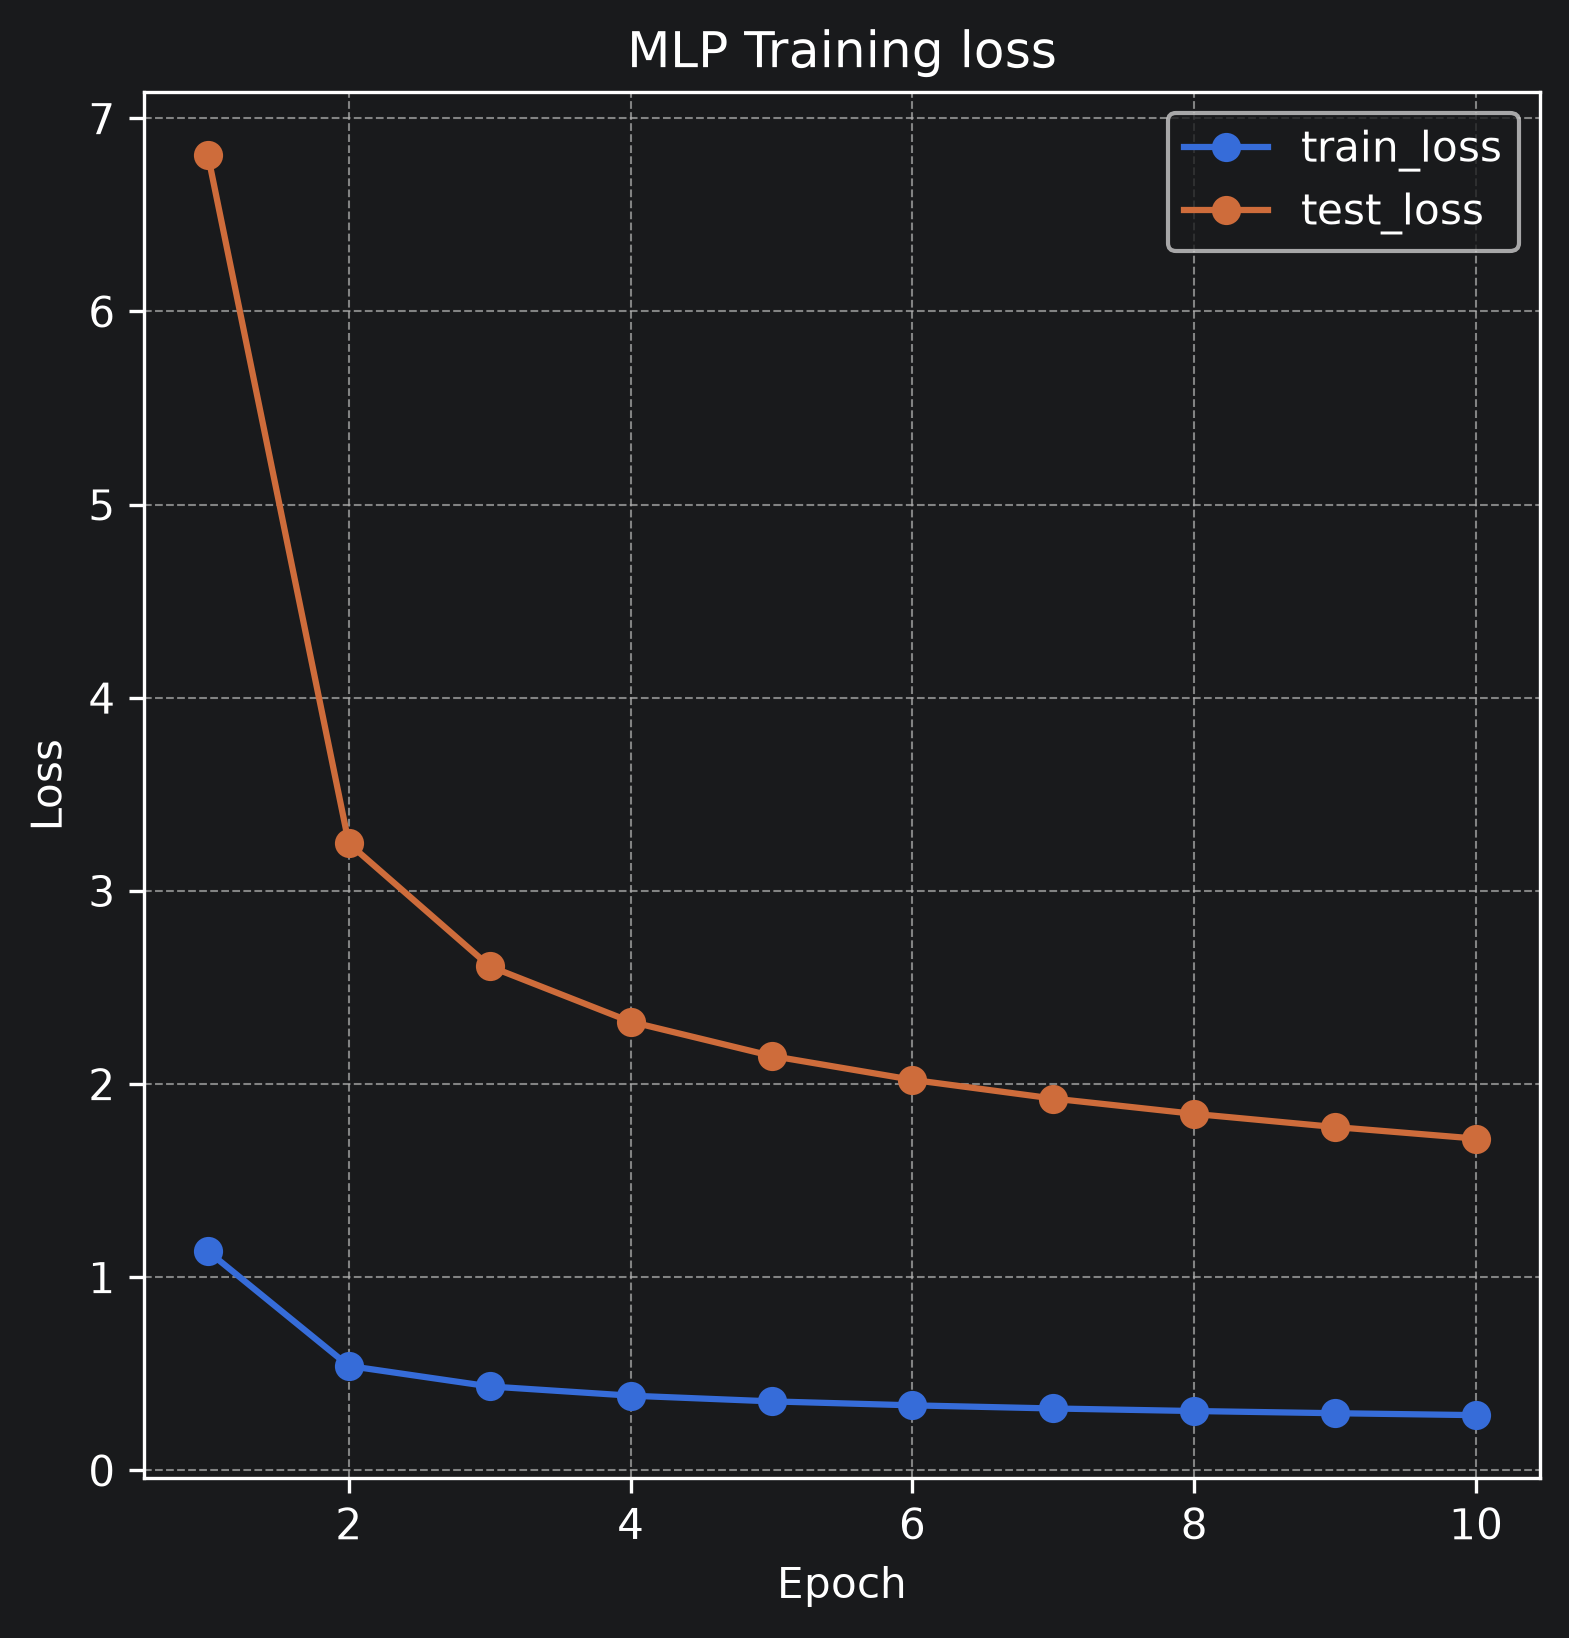

In [12]:
"""
观察训练曲线
"""
fig = plt.figure(2, figsize=(6, 6))
ax = fig.add_subplot(1, 1, 1)
xticks = np.arange(1, num_epochs + 1)
ax.plot(xticks, history['loss'], marker='o')
ax.plot(xticks, history["test_loss"], marker='o')
ax.grid(linestyle='--', alpha=0.7)
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend(['train_loss', 'test_loss'])
ax.set_title("MLP Training loss")
plt.show()

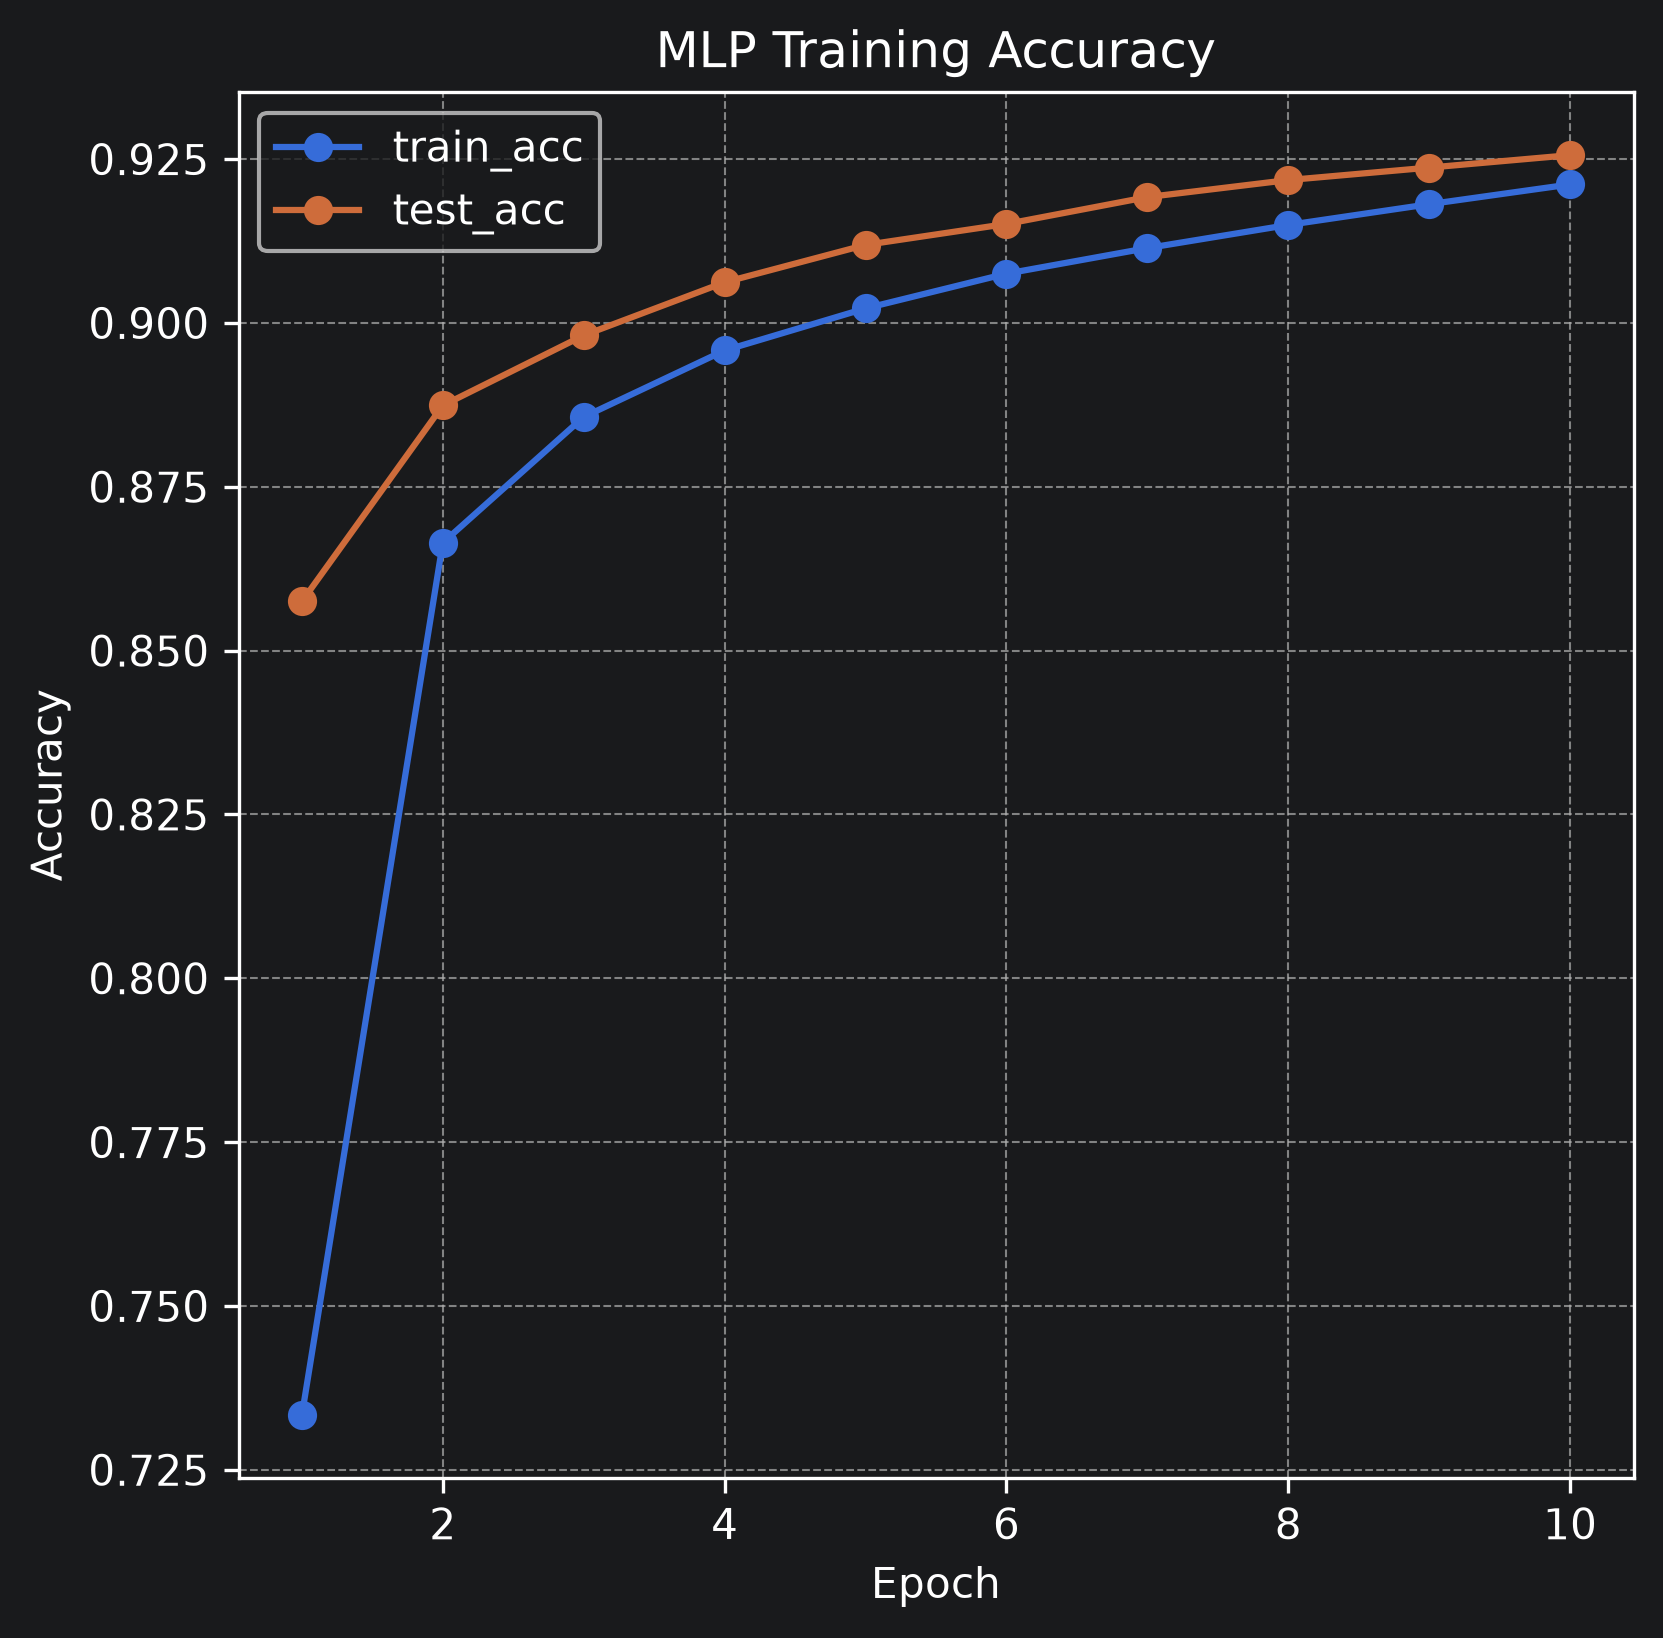

In [13]:
fig = plt.figure(2, figsize=(6, 6))
ax = fig.add_subplot(1, 1, 1)
xticks = np.arange(1, num_epochs + 1)
ax.plot(xticks, history['acc'], marker='o')
ax.plot(xticks, history["test_acc"], marker='o')
ax.grid(linestyle='--', alpha=0.7)
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy")
ax.legend(['train_acc', 'test_acc'])
ax.set_title("MLP Training Accuracy")
plt.show()

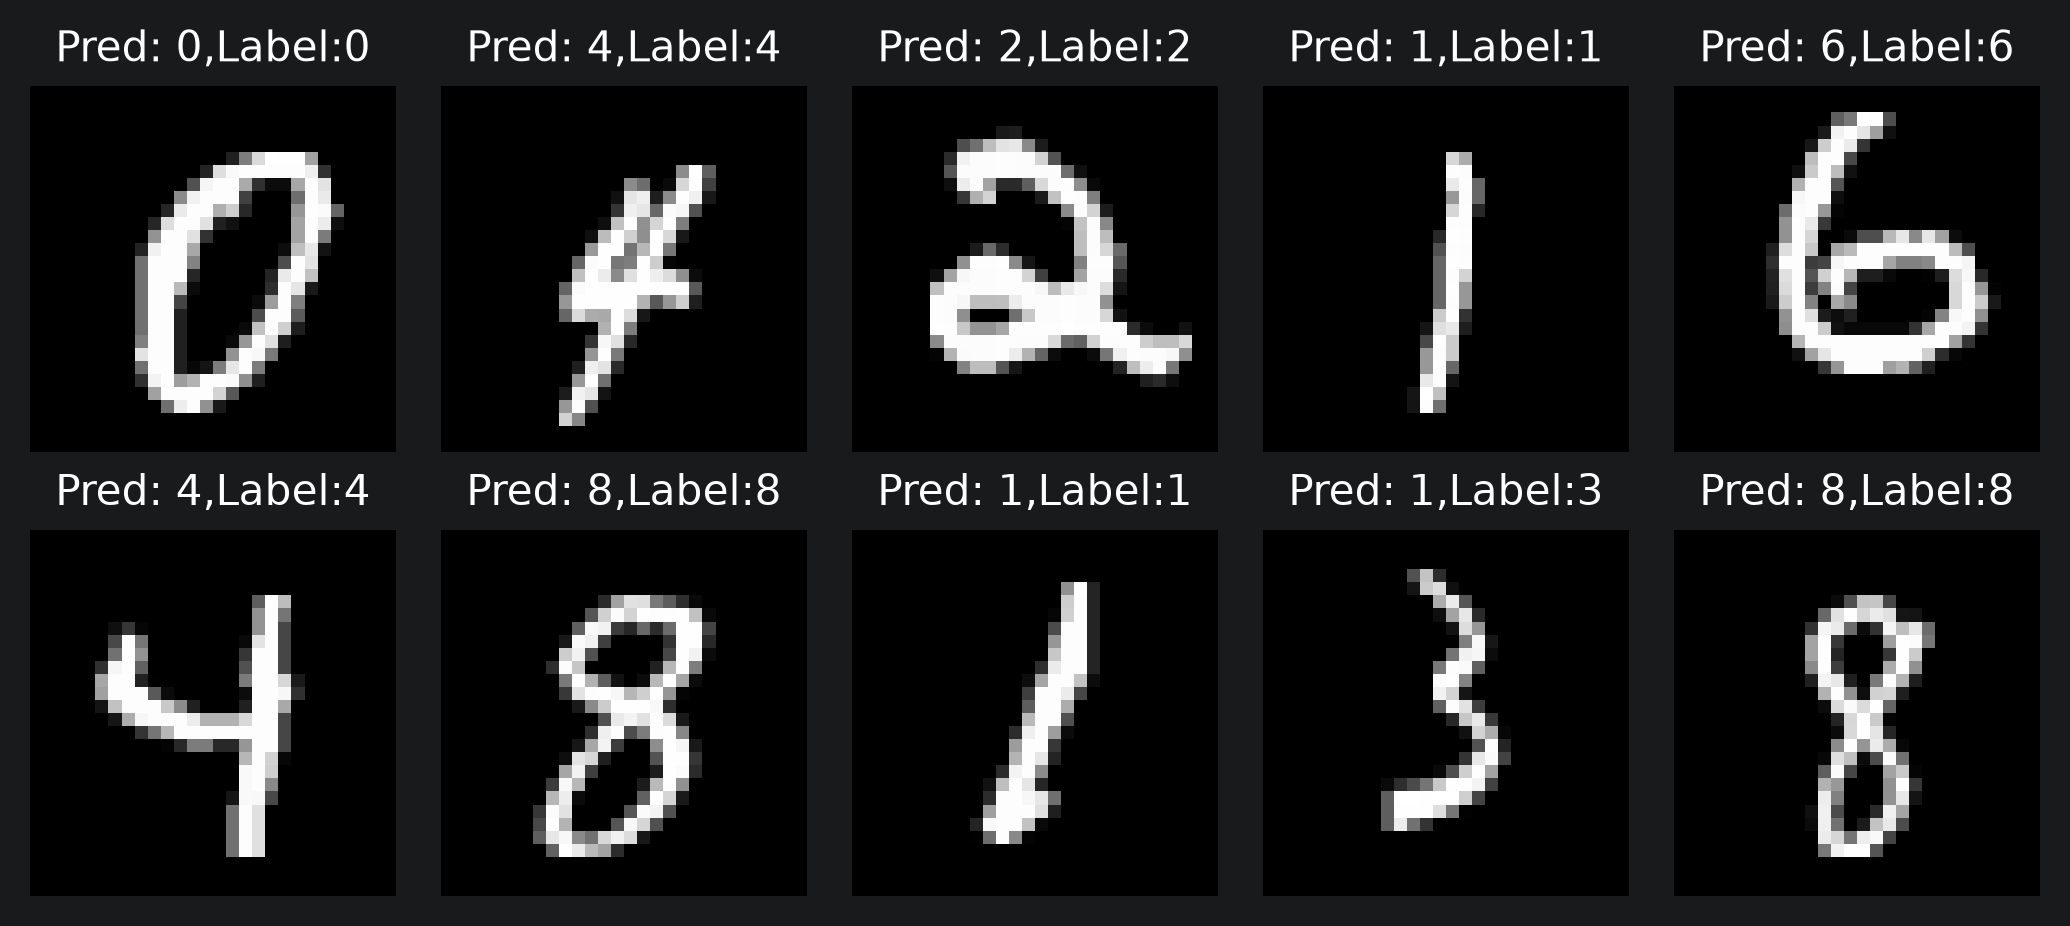

In [18]:
"""
查看预测结果
"""

indices = rng.choice(len(x_test), size=10, replace=False)
x_sample = x_test[indices]
y_sample = y_test[indices]

logits = model(x_sample)
y_preds = np.argmax(logits, axis=1)

# 可视化这些样本
fig =  plt.figure(3,figsize=(7,3.2))
axes =  fig.subplots(2,5)
for i ,ax in enumerate(axes.ravel()):
    ax.imshow(x_sample[i].reshape(28, 28), cmap='gray')
    ax.axis('off')
    ax.set_title(f"Pred: {y_preds[i]},Label:{y_sample[i]}", fontsize=10)
fig.tight_layout()
plt.show()